## Bar plot of remaining sources of Fan data not presented in main figures

In [ ]:
# python version- 3.10.14 - to be compatible with Marsilea tool

In [1]:
import scanpy as sc
import anndata
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import marsilea as ma
import marsilea.plotter as mp

In [2]:
adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Fan_brain_met/Xing_rds/batch_none/Fan_nk_eMLclassified_adata_batch_none_classification_patientID_Tcell_filtered.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 9086 × 33694
    obs: 'Disease', 'Study', 'SampleID', 'CancerType', 'CancerSubtype', 'EGFRtype', 'Treatment', 'Celltype', 'Subtype', 'batch', 'celltype.l2', 'dataset_name', 'classification', 'PatientID'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [4]:
adata.obs["classification"].value_counts()

classification
CD56dim          5106
ML1              1706
CD56bright        769
ML_transition     729
ML2               438
unclassified      338
Name: count, dtype: int64

In [5]:
adata.obs.groupby("CancerSubtype")["PatientID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_7719/724157824.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("CancerSubtype")["PatientID"].nunique()


CancerSubtype
BC-HR+HER2+     4
BC-HR+HER2-     2
BC-HR-HER2+     6
BC-TNBC         4
LC-SCLC         5
NSCLC-LCLC      3
NSCLC-LUAD     27
NSCLC-LUSC      3
Other          23
Name: PatientID, dtype: int64

In [6]:
adata.obs.groupby("CancerType")["PatientID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_54305/3386323913.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("CancerType")["PatientID"].nunique()


CancerType
BC         16
CRC         7
ESCC        3
HCC         3
LC         39
MEL         1
Other       4
Sarcoma     4
Name: PatientID, dtype: int64

In [7]:
# define subtypes to exclude which are already included in main figures
exclude_subtypes = [
    "BC-HR+HER2+",
    "BC-HR+HER2-",
    "BC-HR-HER2+",
    "BC-TNBC",
    "NSCLC-LUAD"]

# filter the dataframe
filtered_obs = adata.obs[~adata.obs["CancerSubtype"].isin(exclude_subtypes)]

# recompute counts
filtered_obs.groupby("CancerSubtype")["PatientID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_7719/2012853408.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  filtered_obs.groupby("CancerSubtype")["PatientID"].nunique()


CancerSubtype
BC-HR+HER2+     0
BC-HR+HER2-     0
BC-HR-HER2+     0
BC-TNBC         0
LC-SCLC         5
NSCLC-LCLC      3
NSCLC-LUAD      0
NSCLC-LUSC      3
Other          23
Name: PatientID, dtype: int64

In [8]:
adata = adata[~adata.obs["CancerSubtype"].isin(exclude_subtypes)].copy()

In [9]:
adata.obs.groupby("CancerSubtype")["PatientID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_7719/724157824.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("CancerSubtype")["PatientID"].nunique()


CancerSubtype
LC-SCLC        5
NSCLC-LCLC     3
NSCLC-LUSC     3
Other         23
Name: PatientID, dtype: int64

In [10]:
adata.obs.groupby("CancerType")["PatientID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_7719/3386323913.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("CancerType")["PatientID"].nunique()


CancerType
CRC         7
ESCC        3
HCC         3
LC         12
MEL         1
Other       4
Sarcoma     4
Name: PatientID, dtype: int64

In [13]:
plt.rcParams['figure.dpi'] = 600

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_7719/4200636936.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = obs.groupby(['CancerType', 'SampleID', 'classification']).size().unstack(fill_value=0)
/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_7719/4200636936.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_source = percentages.groupby('CancerType')[ml_classes].mean()
/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_7719/4200636936.py:27: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In 

(0.0, 89.7468718496116)

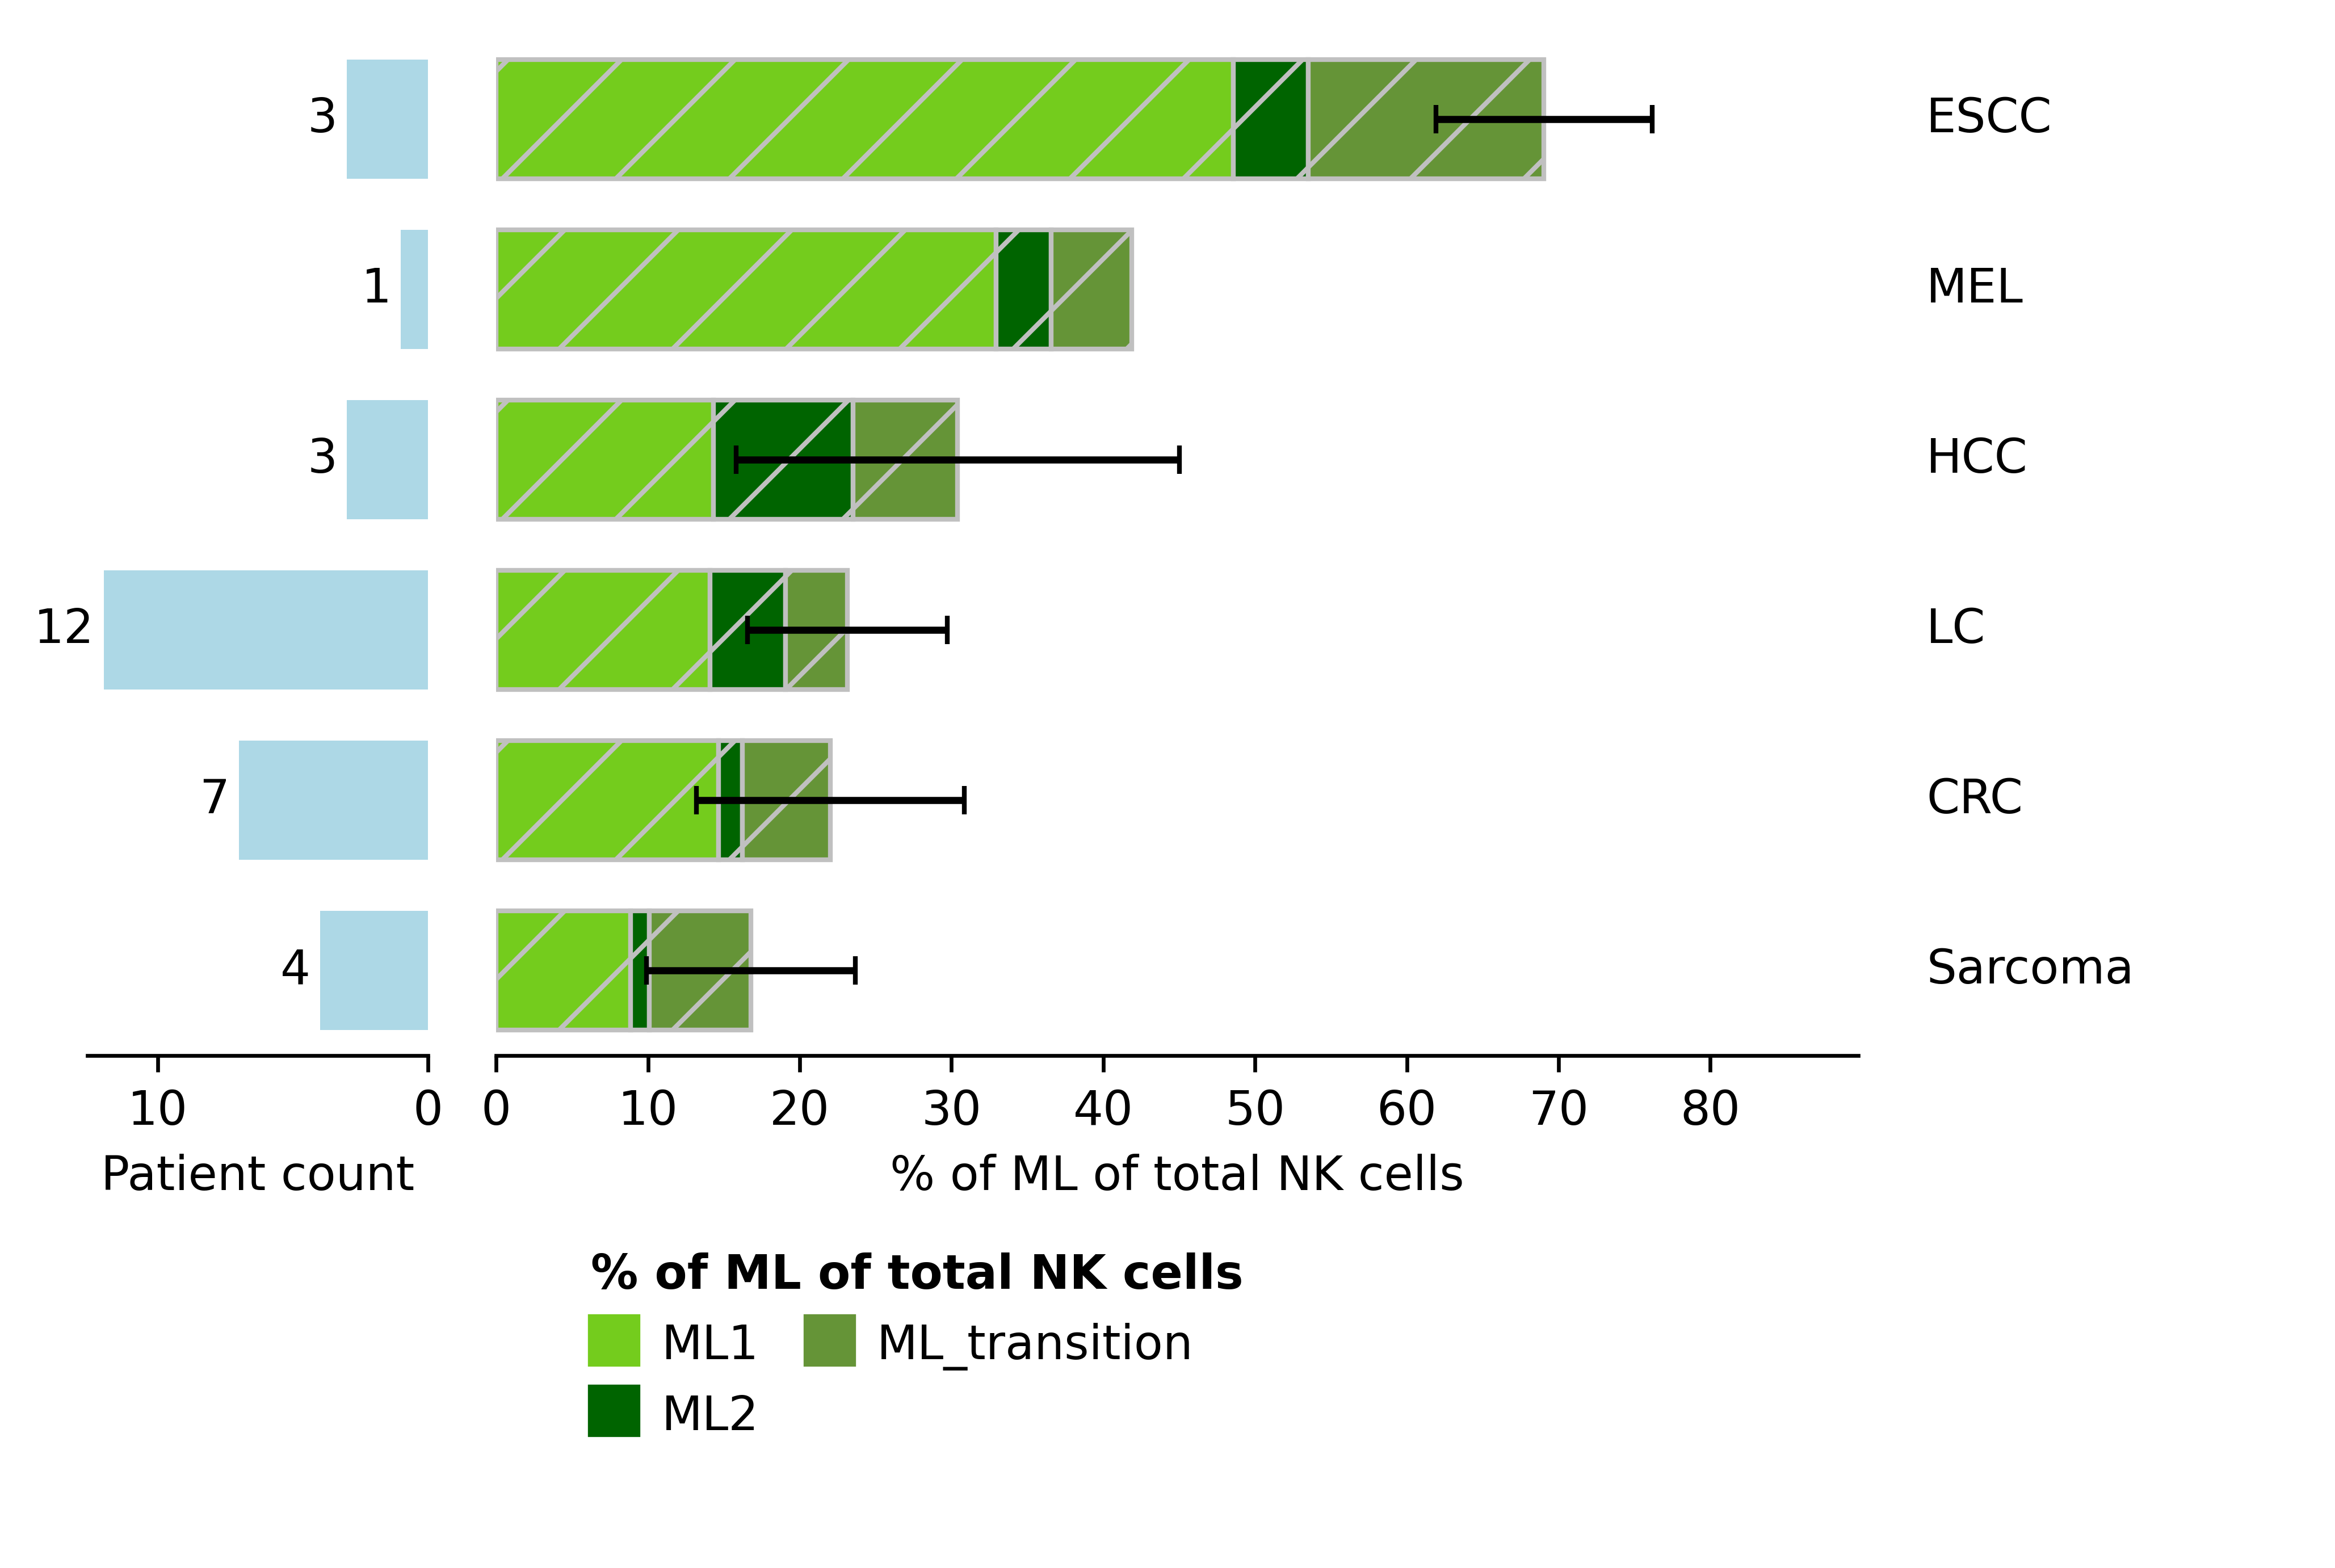

In [14]:
# ML categories
ml_classes = ["ML1", "ML2", "ML_transition"]

# prep obs, drop 'Other' 
obs = adata.obs.copy()
obs = obs[obs['CancerType'] != 'Other']
obs['CancerType'] = obs['CancerType'].cat.remove_unused_categories()

# compute percentages per sample 
grouped = obs.groupby(['CancerType', 'SampleID', 'classification']).size().unstack(fill_value=0)
percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100

# compute mean per CancerType (ML categories only) 
mean_per_source = percentages.groupby('CancerType')[ml_classes].mean()

# Sort by total ML percentage descending
mean_per_source = mean_per_source.loc[
    mean_per_source.sum(axis=1).sort_values(ascending=False).index]

# compute combined ML SEM
obs_sem = obs.copy()
obs_sem['classification'] = obs_sem['classification'].replace({
    'ML1': 'ML_combined', 'ML2': 'ML_combined', 'ML_transition': 'ML_combined'
})
grouped_sem = obs_sem.groupby(['CancerType', 'SampleID', 'classification']).size().unstack(fill_value=0)
percentages_sem = grouped_sem.div(grouped_sem.sum(axis=1), axis=0) * 100

mean_ml_combined = percentages_sem.groupby('CancerType')['ML_combined'].mean()
sem_ml_combined  = percentages_sem.groupby('CancerType')['ML_combined'].sem()

# Align to sorted index
mean_ml_combined = mean_ml_combined.reindex(mean_per_source.index)
sem_ml_combined  = sem_ml_combined.reindex(mean_per_source.index)

# define colors 
colors = {"ML1": "#74cc1d", "ML2": "darkgreen", "ML_transition": "#659437"}
palette = [colors[c] for c in ml_classes]

# hatch patterns per CancerType 
hatch_patterns = ['/'] * len(mean_per_source)

patient_counts = obs.groupby('CancerType')['PatientID'].nunique().reindex(mean_per_source.index)

# build StackBar
sb = mp.StackBar(
    mean_per_source.T,
    colors=palette,
    width=0.7,
    orient="h",
    label="% of ML of total NK cells",
    hatch=hatch_patterns,
    edgecolor='silver',
    legend_kws={'ncol': 2, 'fontsize': 10}
)

# build ClusterBoard
cb = ma.ClusterBoard(mean_per_source.to_numpy(), height=3, margin=0.5)
cb.add_layer(sb)

# add left - sample counts
fmt = lambda x: f"{int(x)}" if x > 0 else ""
samples_layer = mp.Numbers(
    patient_counts,
    label="Patient count",
    fmt=fmt,
    color="lightblue", width=0.7
)
cb.add_left(samples_layer, pad=0.2, name="samples")

# add right - CancerType labels 
cancer_labels = mp.Labels(mean_per_source.index)
cb.add_right(cancer_labels, size=1.1, pad=0.2)

# render 
cb.add_legends("bottom", pad=0.3)
cb.render()

# add SEM error bars
ax = cb.get_main_ax()
x_edge     = mean_per_source[ml_classes].sum(axis=1).values
y_centers  = np.arange(len(mean_per_source))[::-1] + 0.5

ax.errorbar(
    x=x_edge,
    y=y_centers,
    xerr=sem_ml_combined.values,
    fmt='none',
    ecolor='black',
    capsize=3,
    zorder=10)

# adjust x-axis
ax.set_xlim(0, mean_per_source.sum(axis=1).max() * 1.3)

In [17]:
source_to_group =  {
    'ESCC': 'Esophagus',
    'Melanoma': 'Skin',
    'HCC': 'Liver',
    'CRC': 'Colorectal',
    'Sarcoma': 'Sarcoma',
}
order = ['Esophagus', 'Skin', 'Liver', 'Colorectal', 'Sarcoma']

In [21]:
# Add grouping 
source_group_labels = [source_to_group.get(src, 'Other') for src in mean_per_source.index]

print("Cancer types in data:", mean_per_source.index.tolist())
print("Group labels created:", source_group_labels)
print("Unique groups in data:", list(set(source_group_labels)))
print("Order requested:", order)

Cancer types in data: ['ESCC', 'MEL', 'HCC', 'LC', 'CRC', 'Sarcoma']
Group labels created: ['Esophagus', 'Other', 'Liver', 'Other', 'Colorectal', 'Sarcoma']
Unique groups in data: ['Other', 'Sarcoma', 'Liver', 'Esophagus', 'Colorectal']
Order requested: ['Esophagus', 'Skin', 'Liver', 'Colorectal', 'Sarcoma']


In [42]:
source_to_group = {
    'ESCC': 'Esophagus',
    'MEL': 'Skin',
    'HCC': 'Liver',
    'LC': 'Lung',
    'CRC': 'Colorectal',
    'Sarcoma': 'Sarcoma',
}

order = ['Esophagus', 'Skin', 'Liver', 'Lung', 'Colorectal', 'Sarcoma']

# M status
N_T = {
    'ESCC': 'M',
    'MEL': 'M',
    'HCC': 'M',
    'LC': 'M',
    'CRC': 'M',
    'Sarcoma': 'M',
}
nt_labels = [N_T.get(src, 'N') for src in mean_per_source.index]

# StackBar 
sb = mp.StackBar(
    mean_per_source.T,
    colors=palette,
    width=0.7,
    orient="h",
    label="% of iML of total NK cells",
    legend_kws={'ncol': 2, 'fontsize': 35},)

# Build ClusterBoard 
cb = ma.ClusterBoard(mean_per_source.to_numpy(), height=10, margin=0.5)
cb.add_layer(sb)

# Add N/T labels layer 
nt_text_layer = mp.Labels(nt_labels)
cb.add_left(nt_text_layer, pad=0.01, size=0.2, name="N/T_text")

# Add patient counts
fmt = lambda x: f"{int(x)}" if x > 0 else ""
patients_layer = mp.Numbers(
    patient_counts.loc[mean_per_source.index],
    label="Patient count",
    fmt=fmt,
    color="lightblue", props={'fontsize': 25}
)
cb.add_left(patients_layer, pad=0.2, name="patients")

# Add source labels
source_labels = mp.Labels(mean_per_source.index)
cb.add_right(source_labels, size=1.1, pad=0.2)

# Add grouping 
source_group_labels = [source_to_group.get(src, 'Other') for src in mean_per_source.index]
cb.group_rows(source_group_labels, order=order)

# Add chunk colors 
chunk_text = order  
group_color = ["#e5e7eb", "lightcoral", 'steelblue', "peru", "mediumaquamarine", "khaki"]
cb.add_left(mp.Chunk(chunk_text, group_color, rotation=0, padding=10, props={'fontsize': 22}), pad=0.4)

# Add legends and render 
#cb.add_legends("bottom", pad=0.3)
cb.render()

# Increase axis label font size
for ax in cb.get_main_ax():
    ax.set_xlabel(ax.get_xlabel(), fontsize=25)
    
# --- required 3.10 for pairwise function to work ---
from itertools import pairwise

# Get the list of axes and breakpoints
main_ax_list = cb.get_main_ax()
breakpoints = cb.get_deform().row_breakpoints

# Calculate error bar data
combined_widths = mean_per_source[ml_classes].sum(axis=1).values
x_edge = combined_widths
sem_values = sem_ml_combined.reindex(mean_per_source.index).values

# Add error bars to each group separately
for ((start_idx, end_idx), ax) in zip(pairwise(breakpoints), main_ax_list):
    group_size = end_idx - start_idx
    x_positions = x_edge[start_idx:end_idx]
    error_vals = sem_values[start_idx:end_idx]
    y_positions = np.arange(group_size)[::-1] + 0.5
    
    ax.errorbar(
        x=x_positions,
        y=y_positions,
        xerr=error_vals,
        fmt='none',
        ecolor='black',
        capsize=3,
        zorder=10
    )
    ax.set_xlim(0, mean_per_source.sum(axis=1).max() * 1.5)
    ax.tick_params(axis='x', labelsize=25)

# Enhanced M styling 
try:
    nt_axes = cb.get_ax("N/T_text")
    axes_list = nt_axes if isinstance(nt_axes, list) else [nt_axes]
    
    for ((start_idx, end_idx), nt_ax) in zip(pairwise(breakpoints), axes_list):
        # Get the M labels for this group
        group_nt_labels = nt_labels[start_idx:end_idx]
        
        for i, text_obj in enumerate(nt_ax.texts):
            if i < len(group_nt_labels):
                label = group_nt_labels[i]
                text_obj.set_fontweight('bold')
                text_obj.set_fontsize(12)
                text_obj.set_ha('center')
                
                # Purple background for M
                bg_color = '#8B0000'
                
                bbox_props = dict(boxstyle="round,pad=0.4",
                                  facecolor=bg_color, alpha=0.9,
                                  edgecolor='white', linewidth=1)
                text_obj.set_color('white')
                text_obj.set_bbox(bbox_props)
                
except Exception as e:
    print(f"M styling failed: {e}")


fig = plt.gcf()
fig.set_size_inches(20, 11)
fig.tight_layout()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_7719/3604458664.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
